In [17]:
# ═══════════════════════════════════════════════════════════
# Notebook 05 — Model Selection + Random Forest + SHAP
# Microreactor Siting — Philippines
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import os

PROCESSED = r"C:\Users\ailene.nunez\Downloads\microreactor_siting\data\processed"
FIGURES   = r"C:\Users\ailene.nunez\Downloads\microreactor_siting\figures"
os.makedirs(FIGURES, exist_ok=True)

TARGET_H, TARGET_W = 2000, 1600

# ═══════════════════════════════════════════════════════════
# SECTION 1 — Load all layers at 1km resolution
# ═══════════════════════════════════════════════════════════

def load_1km(path):
    with rasterio.open(path) as src:
        return src.read(
            1,
            out_shape=(TARGET_H, TARGET_W),
            resampling=Resampling.bilinear
        ).astype(np.float32)

print("Loading feature layers...")
exclusion   = load_1km(f"{PROCESSED}/master_exclusion_mask.tif")
suitability = load_1km(f"{PROCESSED}/suitability_1km.tif")
dist_pop    = load_1km(f"{PROCESSED}/dist_pop.tif")
dist_port   = load_1km(f"{PROCESSED}/dist_port.tif")
dist_road   = load_1km(f"{PROCESSED}/dist_road.tif")
dist_river  = load_1km(f"{PROCESSED}/dist_river.tif")
pop_dens    = load_1km(f"{PROCESSED}/population_density.tif")
dem         = load_1km(f"{PROCESSED}/dem_4326.tif")

# Derive slope from DEM
dy, dx = np.gradient(dem.astype(np.float64), 1000, 1000)
slope  = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2))).astype(np.float32)
del dx, dy
print("  ✅ All layers loaded")

Loading feature layers...
  ✅ All layers loaded


In [18]:
# ═══════════════════════════════════════════════════════════
# SECTION 2 — Create class labels from suitability scores
# ═══════════════════════════════════════════════════════════

# Class 0: Unsuitable  — excluded or score < 40
# Class 1: Marginal    — score 40–70
# Class 2: Suitable    — score >= 70

mask   = exclusion < 0.5
labels = np.full((TARGET_H, TARGET_W), -1, dtype=np.int8)
labels[~mask]                                              = 0
labels[mask & (suitability <  40)]                        = 0
labels[mask & (suitability >= 40) & (suitability <  70)] = 1
labels[mask & (suitability >= 70)]                        = 2

print("\nClass distribution:")
class_names = ["Unsuitable", "Marginal", "Suitable"]
for c, name in enumerate(class_names):
    n = (labels == c).sum()
    print(f"  Class {c} ({name}): {n:,} pixels ({n/labels.size*100:.1f}%)")


Class distribution:
  Class 0 (Unsuitable): 3,043,810 pixels (95.1%)
  Class 1 (Marginal): 105,879 pixels (3.3%)
  Class 2 (Suitable): 50,311 pixels (1.6%)


In [19]:
# ═══════════════════════════════════════════════════════════
# SECTION 3 — Build feature matrix
# ═══════════════════════════════════════════════════════════

feature_names = [
    "dist_pop", "dist_port", "dist_road",
    "dist_river", "pop_density", "slope", "elevation"
]

X_full = np.stack([
    dist_pop.flatten(),
    dist_port.flatten(),
    dist_road.flatten(),
    dist_river.flatten(),
    pop_dens.flatten(),
    slope.flatten(),
    dem.flatten()
], axis=1)

y_full = labels.flatten()

# Remove nodata pixels
valid  = y_full >= 0
X_full = X_full[valid]
y_full = y_full[valid]

print(f"\nFeature matrix: {X_full.shape}")
print(f"Label vector:   {y_full.shape}")


Feature matrix: (3200000, 7)
Label vector:   (3200000,)


In [20]:
# ═══════════════════════════════════════════════════════════
# SECTION 4 — Stratified sampling (300 per class)
# ═══════════════════════════════════════════════════════════

print("\nSampling 300 per class...")
np.random.seed(42)
X_samp_list, y_samp_list = [], []

for c in [0, 1, 2]:
    idx     = np.where(y_full == c)[0]
    n       = min(300, len(idx))
    sampled = np.random.choice(idx, n, replace=False)
    X_samp_list.append(X_full[sampled])
    y_samp_list.append(y_full[sampled])
    print(f"  Class {c}: {n} samples")

X_sample = np.vstack(X_samp_list)
y_sample = np.concatenate(y_samp_list)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

# Scale features (needed for LazyPredict and some classifiers)
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)


Sampling 300 per class...
  Class 0: 300 samples
  Class 1: 300 samples
  Class 2: 300 samples

Train: 720 | Test: 180


In [21]:
# ═══════════════════════════════════════════════════════════
# SECTION 5 — LazyPredict: compare all classifiers
# ═══════════════════════════════════════════════════════════

print("\n── LazyPredict classifier comparison ─────────────────")
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None
)

models, predictions = clf.fit(X_tr_sc, X_te_sc, y_train, y_test)

print("\nTop 15 models:")
print(models.head(15).to_string())

# Save results
models.to_csv(f"{PROCESSED}/lazypredict_results.csv")
print("\n✅ LazyPredict results saved")



── LazyPredict classifier comparison ─────────────────

Top 15 models:
                             Accuracy  Balanced Accuracy   ROC AUC  F1 Score  Precision    Recall  Time Taken
Model                                                                                                        
ExtraTreesClassifier         0.883333           0.883333  0.941528  0.876668   0.896011  0.883333    0.185387
RandomForestClassifier       0.883333           0.883333  0.939051  0.877882   0.896104  0.883333    0.241970
BaggingClassifier            0.844444           0.844444  0.916944  0.841080   0.847120  0.844444    0.043548
GaussianNB                   0.822222           0.822222  0.905394  0.817140   0.851286  0.822222    0.019958
AdaBoostClassifier           0.822222           0.822222  0.861806  0.817141   0.823157  0.822222    0.180893
LinearSVC                    0.816667           0.816667       NaN  0.814261   0.848497  0.816667    0.020993
SGDClassifier                0.805556           

In [22]:
# ═══════════════════════════════════════════════════════════
# SECTION 6 — Train Random Forest (best tree-based model)
# ═══════════════════════════════════════════════════════════

print("\n── Training Random Forest ─────────────────────────────")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {acc*100:.1f}%")
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=class_names
))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 5-fold cross-validation
cv = cross_val_score(rf, X_sample, y_sample, cv=5, scoring="accuracy")
print(f"\n5-fold CV: {cv.mean()*100:.1f}% ± {cv.std()*100:.1f}%")


── Training Random Forest ─────────────────────────────

Accuracy: 88.3%

Classification Report:
              precision    recall  f1-score   support

  Unsuitable       0.95      0.68      0.80        60
    Marginal       0.88      0.97      0.92        60
    Suitable       0.85      1.00      0.92        60

    accuracy                           0.88       180
   macro avg       0.89      0.88      0.88       180
weighted avg       0.89      0.88      0.88       180

Confusion Matrix:
[[41  8 11]
 [ 2 58  0]
 [ 0  0 60]]

5-fold CV: 89.1% ± 1.7%



Feature Importance (RF Gini):
  dist_pop       : 0.2762
  dist_road      : 0.2666
  dist_river     : 0.2228
  dist_port      : 0.1340
  slope          : 0.0358
  elevation      : 0.0355
  pop_density    : 0.0290


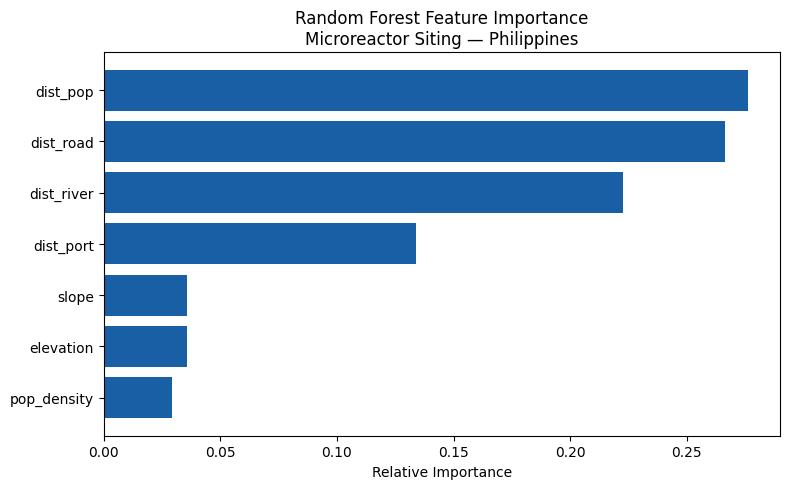

✅ Saved: feature_importance.png


In [23]:
# ═══════════════════════════════════════════════════════════
# SECTION 7 — Standard feature importance plot
# ═══════════════════════════════════════════════════════════

importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1]

print("\nFeature Importance (RF Gini):")
for i in indices:
    print(f"  {feature_names[i]:<15}: {importances[i]:.4f}")

plt.figure(figsize=(8, 5))
plt.barh(
    [feature_names[i] for i in indices[::-1]],
    importances[indices[::-1]],
    color="#185FA5"
)
plt.xlabel("Relative Importance")
plt.title("Random Forest Feature Importance\nMicroreactor Siting — Philippines")
plt.tight_layout()
plt.savefig(f"{FIGURES}/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: feature_importance.png")


Computing SHAP values...
  shap_arr shape: (3, 180, 7)
  shap_class[0] shape: (180, 7)


C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_16980\3201288852.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_16980\3201288852.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_16980\3201288852.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


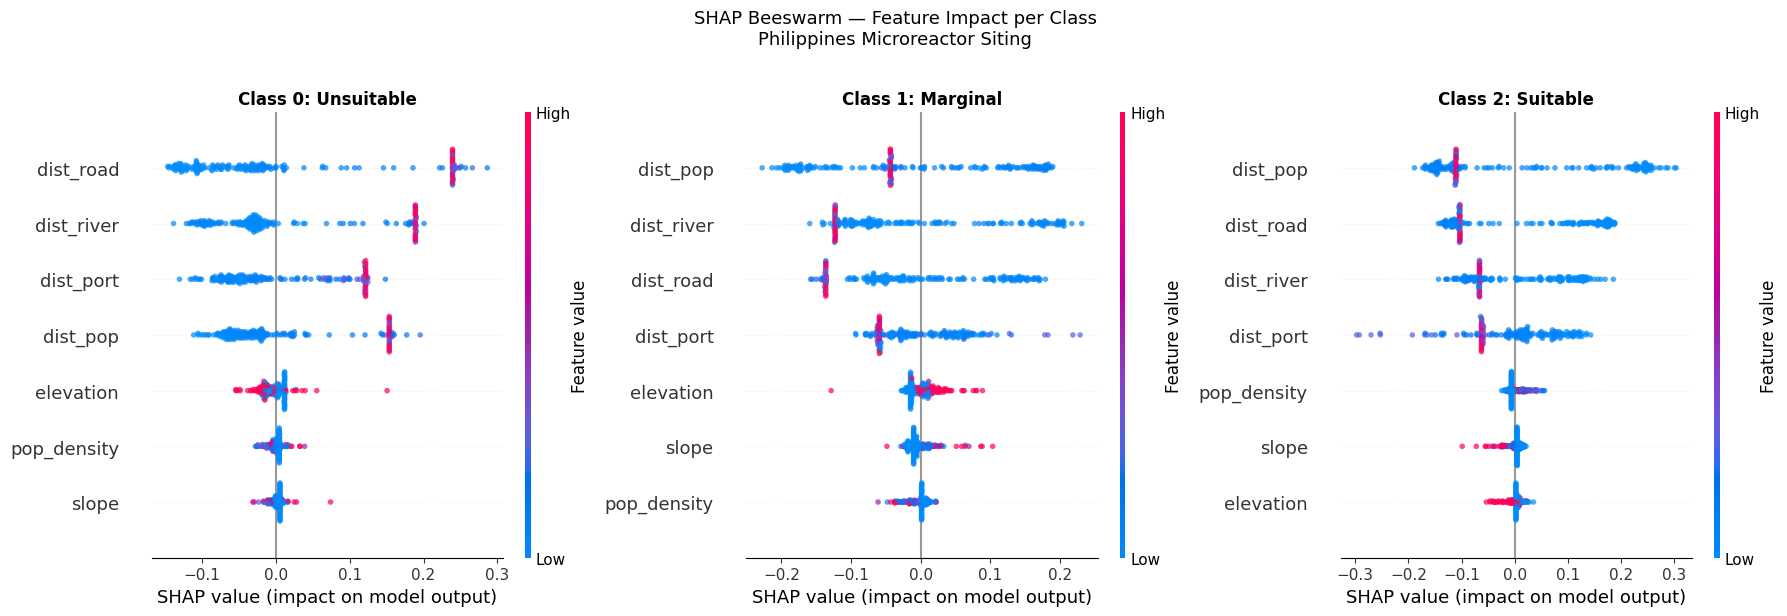

✅ Saved: shap_beeswarm_all.png


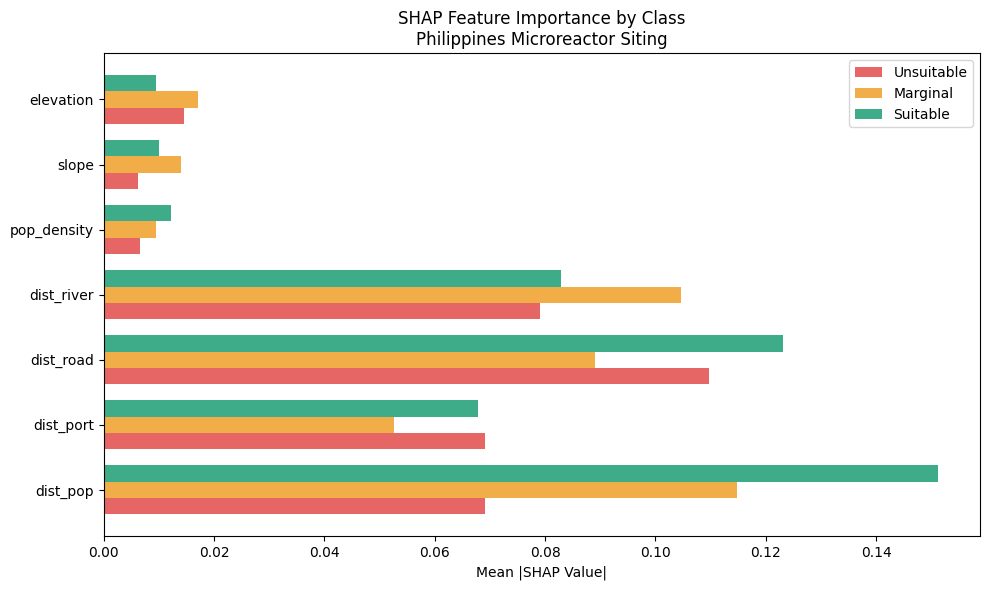

✅ Saved: shap_bar.png


C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_16980\3201288852.py:69: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


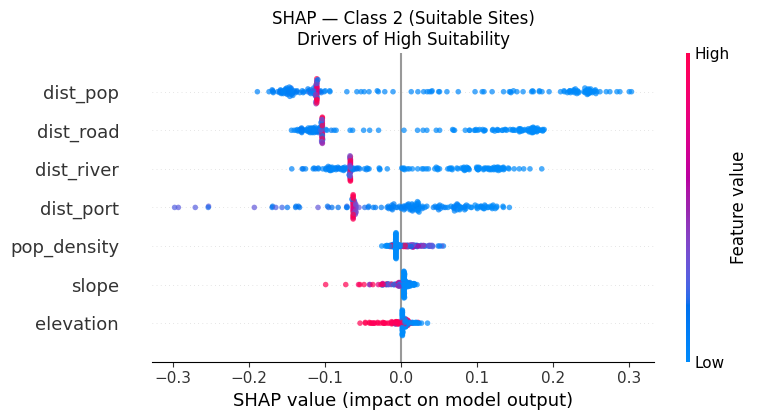

✅ Saved: shap_suitable.png

Mean |SHAP| — Class 2 (Suitable):
  dist_pop       : 0.1513
  dist_road      : 0.1232
  dist_river     : 0.0829
  dist_port      : 0.0678
  pop_density    : 0.0121
  slope          : 0.0099
  elevation      : 0.0094


In [27]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("Computing SHAP values...")

background  = shap.sample(X_train, 100, random_state=42)
explainer   = shap.TreeExplainer(rf, background)
shap_raw    = explainer.shap_values(X_test)

# shap_raw shape is (180, 7, 3) — reshape to (3, 180, 7)
shap_arr    = np.array(shap_raw)          # (180, 7, 3)
shap_arr    = np.transpose(shap_arr, (2, 0, 1))  # → (3, 180, 7)

print(f"  shap_arr shape: {shap_arr.shape}")  # should be (3, 180, 7)

# Split into per-class arrays
shap_class  = [shap_arr[i] for i in range(3)]  # each: (180, 7)
print(f"  shap_class[0] shape: {shap_class[0].shape}")  # should be (180, 7)

class_names = ["Unsuitable", "Marginal", "Suitable"]
colors_hex  = ["#E24B4A", "#EF9F27", "#1D9E75"]

# ── Plot 1: Beeswarm per class ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (ax, name) in enumerate(zip(axes, class_names)):
    plt.sca(ax)
    shap.summary_plot(
        shap_class[i],
        X_test,
        feature_names=feature_names,
        show=False,
        plot_size=None,
        alpha=0.7
    )
    ax.set_title(f"Class {i}: {name}", fontsize=12, fontweight="bold")

plt.suptitle(
    "SHAP Beeswarm — Feature Impact per Class\nPhilippines Microreactor Siting",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(f"{FIGURES}/shap_beeswarm_all.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_beeswarm_all.png")

# ── Plot 2: Bar — mean |SHAP| per class ───────────────────
fig, ax = plt.subplots(figsize=(10, 6))
x     = np.arange(len(feature_names))
width = 0.25

for i, (name, color) in enumerate(zip(class_names, colors_hex)):
    mean_abs = np.abs(shap_class[i]).mean(axis=0)
    ax.barh(x + i*width, mean_abs, width,
            label=name, color=color, alpha=0.85)

ax.set_yticks(x + width)
ax.set_yticklabels(feature_names)
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("SHAP Feature Importance by Class\nPhilippines Microreactor Siting", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_bar.png")

# ── Plot 3: Class 2 (Suitable) beeswarm ───────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_class[2],
    X_test,
    feature_names=feature_names,
    show=False,
    alpha=0.7
)
plt.title("SHAP — Class 2 (Suitable Sites)\nDrivers of High Suitability", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIGURES}/shap_suitable.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_suitable.png")

# ── Numeric summary ────────────────────────────────────────
print("\nMean |SHAP| — Class 2 (Suitable):")
mean_shap = np.abs(shap_class[2]).mean(axis=0)
for i in np.argsort(mean_shap)[::-1]:
    print(f"  {feature_names[i]:<15}: {mean_shap[i]:.4f}")

In [28]:
# ═══════════════════════════════════════════════════════════
# SECTION 9 — Apply RF to full 1km grid
# ═══════════════════════════════════════════════════════════

print("\n── Applying RF to full Philippines grid ───────────────")
X_pred = np.stack([
    dist_pop.flatten(),
    dist_port.flatten(),
    dist_road.flatten(),
    dist_river.flatten(),
    pop_dens.flatten(),
    slope.flatten(),
    dem.flatten()
], axis=1)

# Predict in chunks to avoid memory issues
chunk     = 100000
n         = len(X_pred)
y_map     = np.full(n, -1, dtype=np.int8)
valid_all = (exclusion.flatten() < 0.5)

for start in range(0, n, chunk):
    end  = min(start + chunk, n)
    vmask = valid_all[start:end]
    if vmask.any():
        y_map[start:end][vmask] = rf.predict(X_pred[start:end][vmask])
    if start % 500000 == 0:
        print(f"  Predicted {start:,}/{n:,}")

rf_map = y_map.reshape(TARGET_H, TARGET_W)
print(f"\nRF Classification map:")
for c, name in enumerate(class_names):
    n_c = (rf_map == c).sum()
    print(f"  Class {c} ({name}): {n_c:,} pixels ({n_c/rf_map.size*100:.1f}%)")

# Save RF classification raster
with rasterio.open(f"{PROCESSED}/suitability_1km.tif") as ref:
    profile = ref.profile.copy()
profile.update({"dtype": "int8", "nodata": -1, "compress": "lzw"})

with rasterio.open(f"{PROCESSED}/rf_classification.tif", "w", **profile) as dst:
    dst.write(rf_map.astype(np.int8), 1)
print("✅ RF classification map saved")

# Save model + scaler
joblib.dump(rf,     f"{PROCESSED}/rf_model.pkl")
joblib.dump(scaler, f"{PROCESSED}/scaler.pkl")
print("✅ Model and scaler saved")


── Applying RF to full Philippines grid ───────────────
  Predicted 0/3,200,000
  Predicted 500,000/3,200,000
  Predicted 1,000,000/3,200,000
  Predicted 1,500,000/3,200,000
  Predicted 2,000,000/3,200,000
  Predicted 2,500,000/3,200,000
  Predicted 3,000,000/3,200,000

RF Classification map:
  Class 0 (Unsuitable): 2,113,126 pixels (66.0%)
  Class 1 (Marginal): 133,410 pixels (4.2%)
  Class 2 (Suitable): 54,595 pixels (1.7%)
✅ RF classification map saved
✅ Model and scaler saved
